In [1]:
from pathlib import Path
import subprocess

subprocess.run([
    "scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/"],
    shell=True, check=True)

CompletedProcess(args=['scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/'], returncode=0)

In [46]:
hash_names = {
    "24ac9404254c0ee7cccd53821e73af8c81fb9a46" : "xarray",
    "c277100ed866fc7f3cfae0b6172c5d3ed2ab5bb0" : "flat1GB",
    "eadff10a39c6faf2e486ed108e3a3bc4c2bb77b3" : "baseline",
}

import pandas as pd
import matplotlib.pyplot as plt

prefix = "result-microbenchmark-mmap-"
suffix = ".csv"
result_files = Path("~/sophgo/smokewagon-benchmarks").expanduser().glob(prefix + "*" + suffix)
dfs = []

for f in result_files:
    df = pd.read_csv(f, index_col=0)

    # column name faff
    label = f.name[len(prefix):-len(suffix)].split("-")
    col_label = tuple([label[1], label[0], hash_names.get(label[2])])
    df.columns = pd.MultiIndex.from_tuples([col_label])

    dfs.append(df)

df = pd.concat(dfs, axis=1)
df

filebacked membacked filebacked                     membacked  \
          inactive  inactive smokewagon inactive smokewagon  inactive   
            xarray   flat1GB    flat1GB baseline     xarray  baseline   
threads                                                                 
1           149309     72613      57582   158711      54959    106592   
2            90952     62262      96206    96751      94813     68593   
3            90410     55177      73066    88716      68656     60391   
4            89989     52287      72717    82140      64402     60595   
5            79273     53163      71843    83135      64167     56005   
...            ...       ...        ...      ...        ...       ...   
60           31057     25377      65344    31588      65287     25707   
61           30811     25276      65485    31431      65009     25622   
62           30497     25007      64774    31113      65699     25351   
63           30011     24722      65071    30656      62382     25070   
64           29586     24390      64931    30158      64848     24750   

        filebacked  membacked                   
          inactive smokewagon         inactive  
           flat1GB     xarray flat1GB   xarray  
threads                                         
1           149434      35043   35742    73050  
2            91016      59232   60087    65956  
3            82350      49476   50529    58042  
4            76667      46630   47416    57823  
5            76571      49249   45156    54417  
...            ...        ...     ...      ...  
60           31060      40516   42515    25360  
61           30769      40674   42524    25193  
62           30432      40793   42405    24956  
63           29909      40579   42357    24660  
64           29489      38440   42125    24377  

[64 rows x 10 columns]

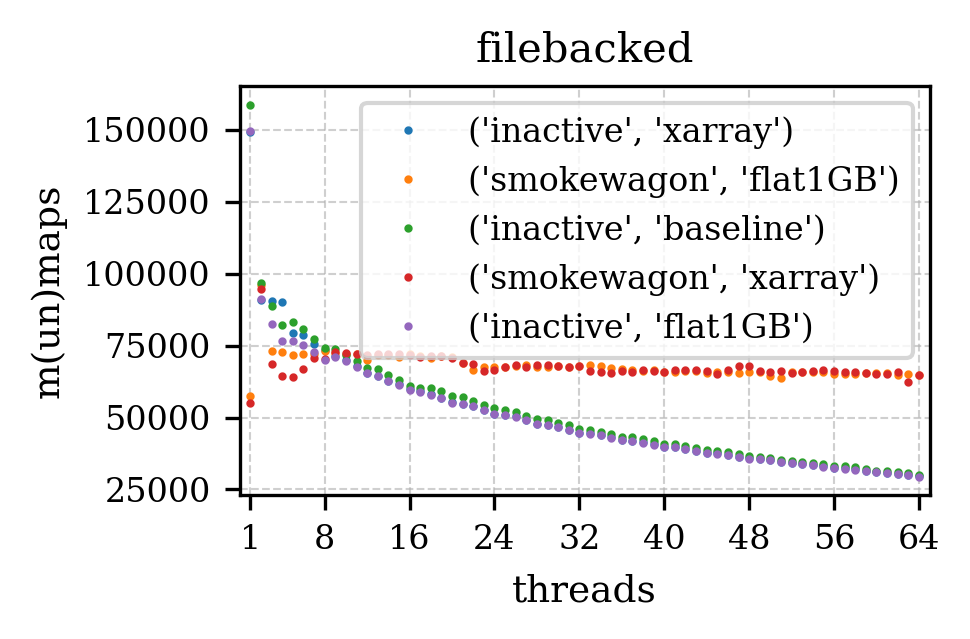

In [47]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df['filebacked'].index, df['filebacked'].values, '.', markersize=2)
ax.set_title("filebacked")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df['filebacked'].columns, frameon=True)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

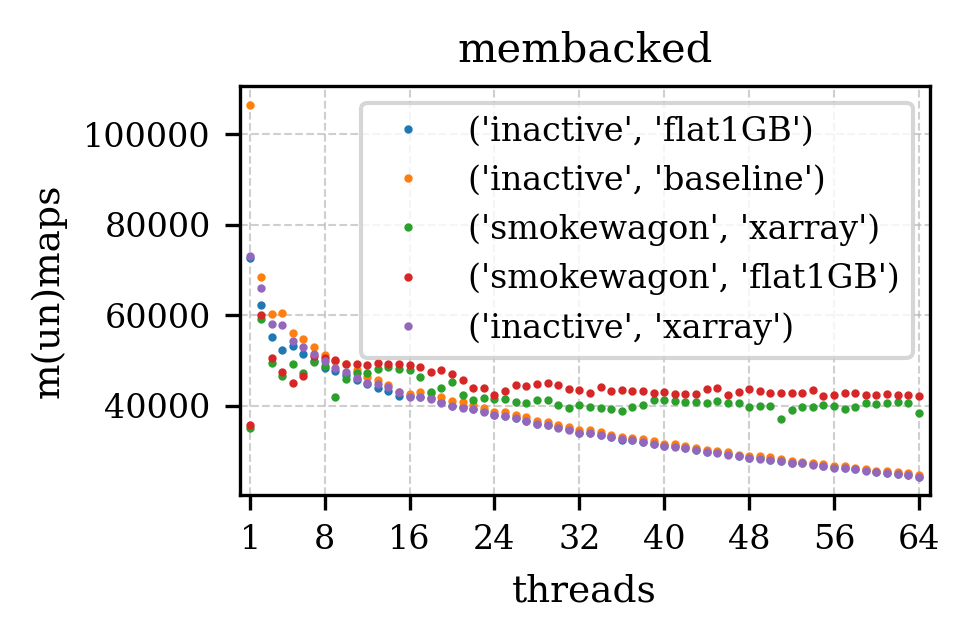

In [48]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df['membacked'].index, df['membacked'].values, '.', markersize=2)
ax.set_title("membacked")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df['membacked'].columns, frameon=True)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")